In [1]:
import numpy as np
from rds import get_rds_connection
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
top_10_cat = [
    'math.AP', 'math.CO', 'math.AG', 'math.PR', 'math.NT',
    'math.DG', 'math.DS', 'math.FA', 'math.RT', 'math.GR'
]

n_per_cat = 5000
placeholders = ', '.join(['%s'] * len(top_10_cat))

QUERY = f"""
WITH ranked AS (
    SELECT
        embedding,
        primary_category,
        ROW_NUMBER() OVER (
            PARTITION BY primary_category
            ORDER BY RANDOM()
        ) AS rn
    FROM theorem_search_qwen
    TABLESAMPLE SYSTEM (2)
    WHERE
        source = 'arXiv'
        AND primary_category IN ({placeholders})
)
SELECT
    embedding,
    primary_category
FROM ranked
WHERE rn <= %s;
"""

conn = get_rds_connection()
cur = conn.cursor()

cur.execute(QUERY, top_10_cat + [n_per_cat])
rows = cur.fetchall()

cur.close()
conn.close()

X = np.array([row[0] for row in rows])
y = np.array([row[1] for row in rows])

print(X.shape)


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

X_scaled = StandardScaler().fit_transform(X)
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

X_umap = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
).fit_transform(X_pca50)

print(X_umap.shape)  # (n_samples, 2)

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(50000, 2)


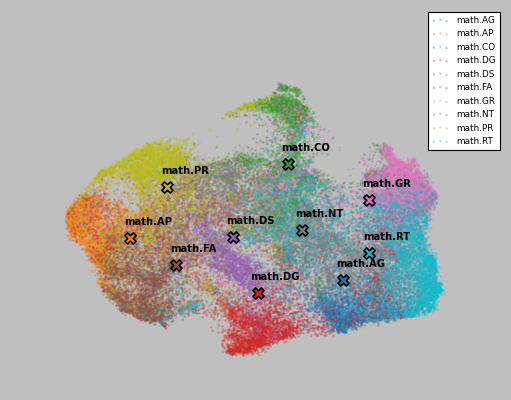

In [84]:
import matplotlib.pyplot as plt
import numpy as np

cats = np.unique(y)
cmap = plt.cm.tab10
cat_to_color = {
    cat: cmap(i / len(cats))
    for i, cat in enumerate(cats)
}

centroids = {
    cat: X_umap[y == cat].mean(axis=0)
    for cat in cats
}

plt.figure(figsize=(8, 6))

for cat in cats:
    idx = y == cat
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        s=2,
        alpha=0.25,
        color=cat_to_color[cat],
        label=cat
    )

# plot centroids (same color, larger, distinct marker)
for cat, c in centroids.items():
    plt.text(
        c[0] + 0.5, c[1] + 0.5,
        cat,
        fontsize=9,
        weight='semibold',
        ha='center',
        va='center'
    ),
    plt.scatter(
        c[0], c[1],
        marker='X',
        s=100,
        color=cat_to_color[cat],
        edgecolors='black',
        linewidths=1.5,
        zorder=10
    )

plt.axis('off')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(fontsize=8)
plt.show()

In [109]:
from dotenv import load_dotenv

from rds import get_rds_connection

load_dotenv()

RANDOM_STATE = 42
TOP_10 = ['math.AP','math.CO','math.AG','math.PR','math.NT', 'math.DG','math.DS','math.FA','math.RT','math.GR']
ARXIV_FULL_NAMES = {
    "math.AC": "Commutative Algebra",
    "math.AG": "Algebraic Geometry",
    "math.AP": "Analysis of PDEs",
    "math.AT": "Algebraic Topology",
    "math.CA": "Classical Analysis and ODEs",
    "math.CO": "Combinatorics",
    "math.CT": "Category Theory",
    "math.CV": "Complex Variables",
    "math.DG": "Differential Geometry",
    "math.DS": "Dynamical Systems",
    "math.FA": "Functional Analysis",
    "math.GM": "General Mathematics",
    "math.GN": "General Topology",
    "math.GR": "Group Theory",
    "math.GT": "Geometric Topology",
    "math.HO": "History and Overview",
    "math.IT": "Information Theory",
    "math.KT": "K-Theory and Homology",
    "math.LO": "Logic",
    "math.MG": "Metric Geometry",
    "math.MP": "Mathematical Physics",
    "math.NA": "Numerical Analysis",
    "math.NT": "Number Theory",
    "math.OA": "Operator Algebras",
    "math.OC": "Optimization and Control",
    "math.PR": "Probability",
    "math.QA": "Quantum Algebra",
    "math.RA": "Rings and Algebras",
    "math.RT": "Representation Theory",
    "math.SG": "Symplectic Geometry",
    "math.SP": "Spectral Theory",
    "math.ST": "Statistics Theory",
}

In [2]:
conn = get_rds_connection()
cur = conn.cursor()

cur.execute("""
SELECT
  theorem_id,
  primary_category,
  raw_embedding,
  slogan_embedding
FROM arxiv_sample_10000;
""")

rows = cur.fetchall()
cur.close()
conn.close()

In [91]:
from sklearn.decomposition import PCA
import umap
import numpy as np

theorem_ids = np.array([r[0] for r in rows])
cats = np.array([r[1] for r in rows])
X_raw = np.array([r[2] for r in rows], dtype=np.float32)
X_slogan = np.array([r[3] for r in rows], dtype=np.float32)

def l2_normalize(X, eps=1e-12):
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)

def independent_umap(X, random_state):
    X = l2_normalize(X.astype(np.float32))

    X_pca = PCA(
        n_components=0.95,
        random_state=random_state
    ).fit_transform(X)

    X_pca = l2_normalize(X_pca)

    Z = umap.UMAP(
        n_neighbors=30,
        min_dist=0.01,
        metric="cosine",
        random_state=random_state,

    ).fit_transform(X_pca)

    return Z

Z_raw = independent_umap(X_raw, RANDOM_STATE)
Z_slogan = independent_umap(X_slogan, RANDOM_STATE)

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [100]:
from scipy.spatial import procrustes
_, _, disparity = procrustes(Z_raw, Z_slogan)
disparity

np.float64(0.750050802132922)

In [113]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "axes.facecolor": "white"
})

unique_cats = np.unique(cats)
cat_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

def compute_centroids(Z, labels, categories):
    centroids = {}
    for cat in categories:
        mask = labels == cat
        centroids[cat] = Z[mask].mean(axis=0)
    return centroids

raw_centroids = compute_centroids(Z_raw, cats, TOP_10)
slogan_centroids = compute_centroids(Z_slogan, cats, TOP_10)

all_x = np.concatenate([Z_raw[:, 0], Z_slogan[:, 0]])
all_y = np.concatenate([Z_raw[:, 1], Z_slogan[:, 1]])
xlim = (all_x.min() - 0.5, all_x.max() + 5)
ylim = (all_y.min() - 0.5, all_y.max() + 0.5)

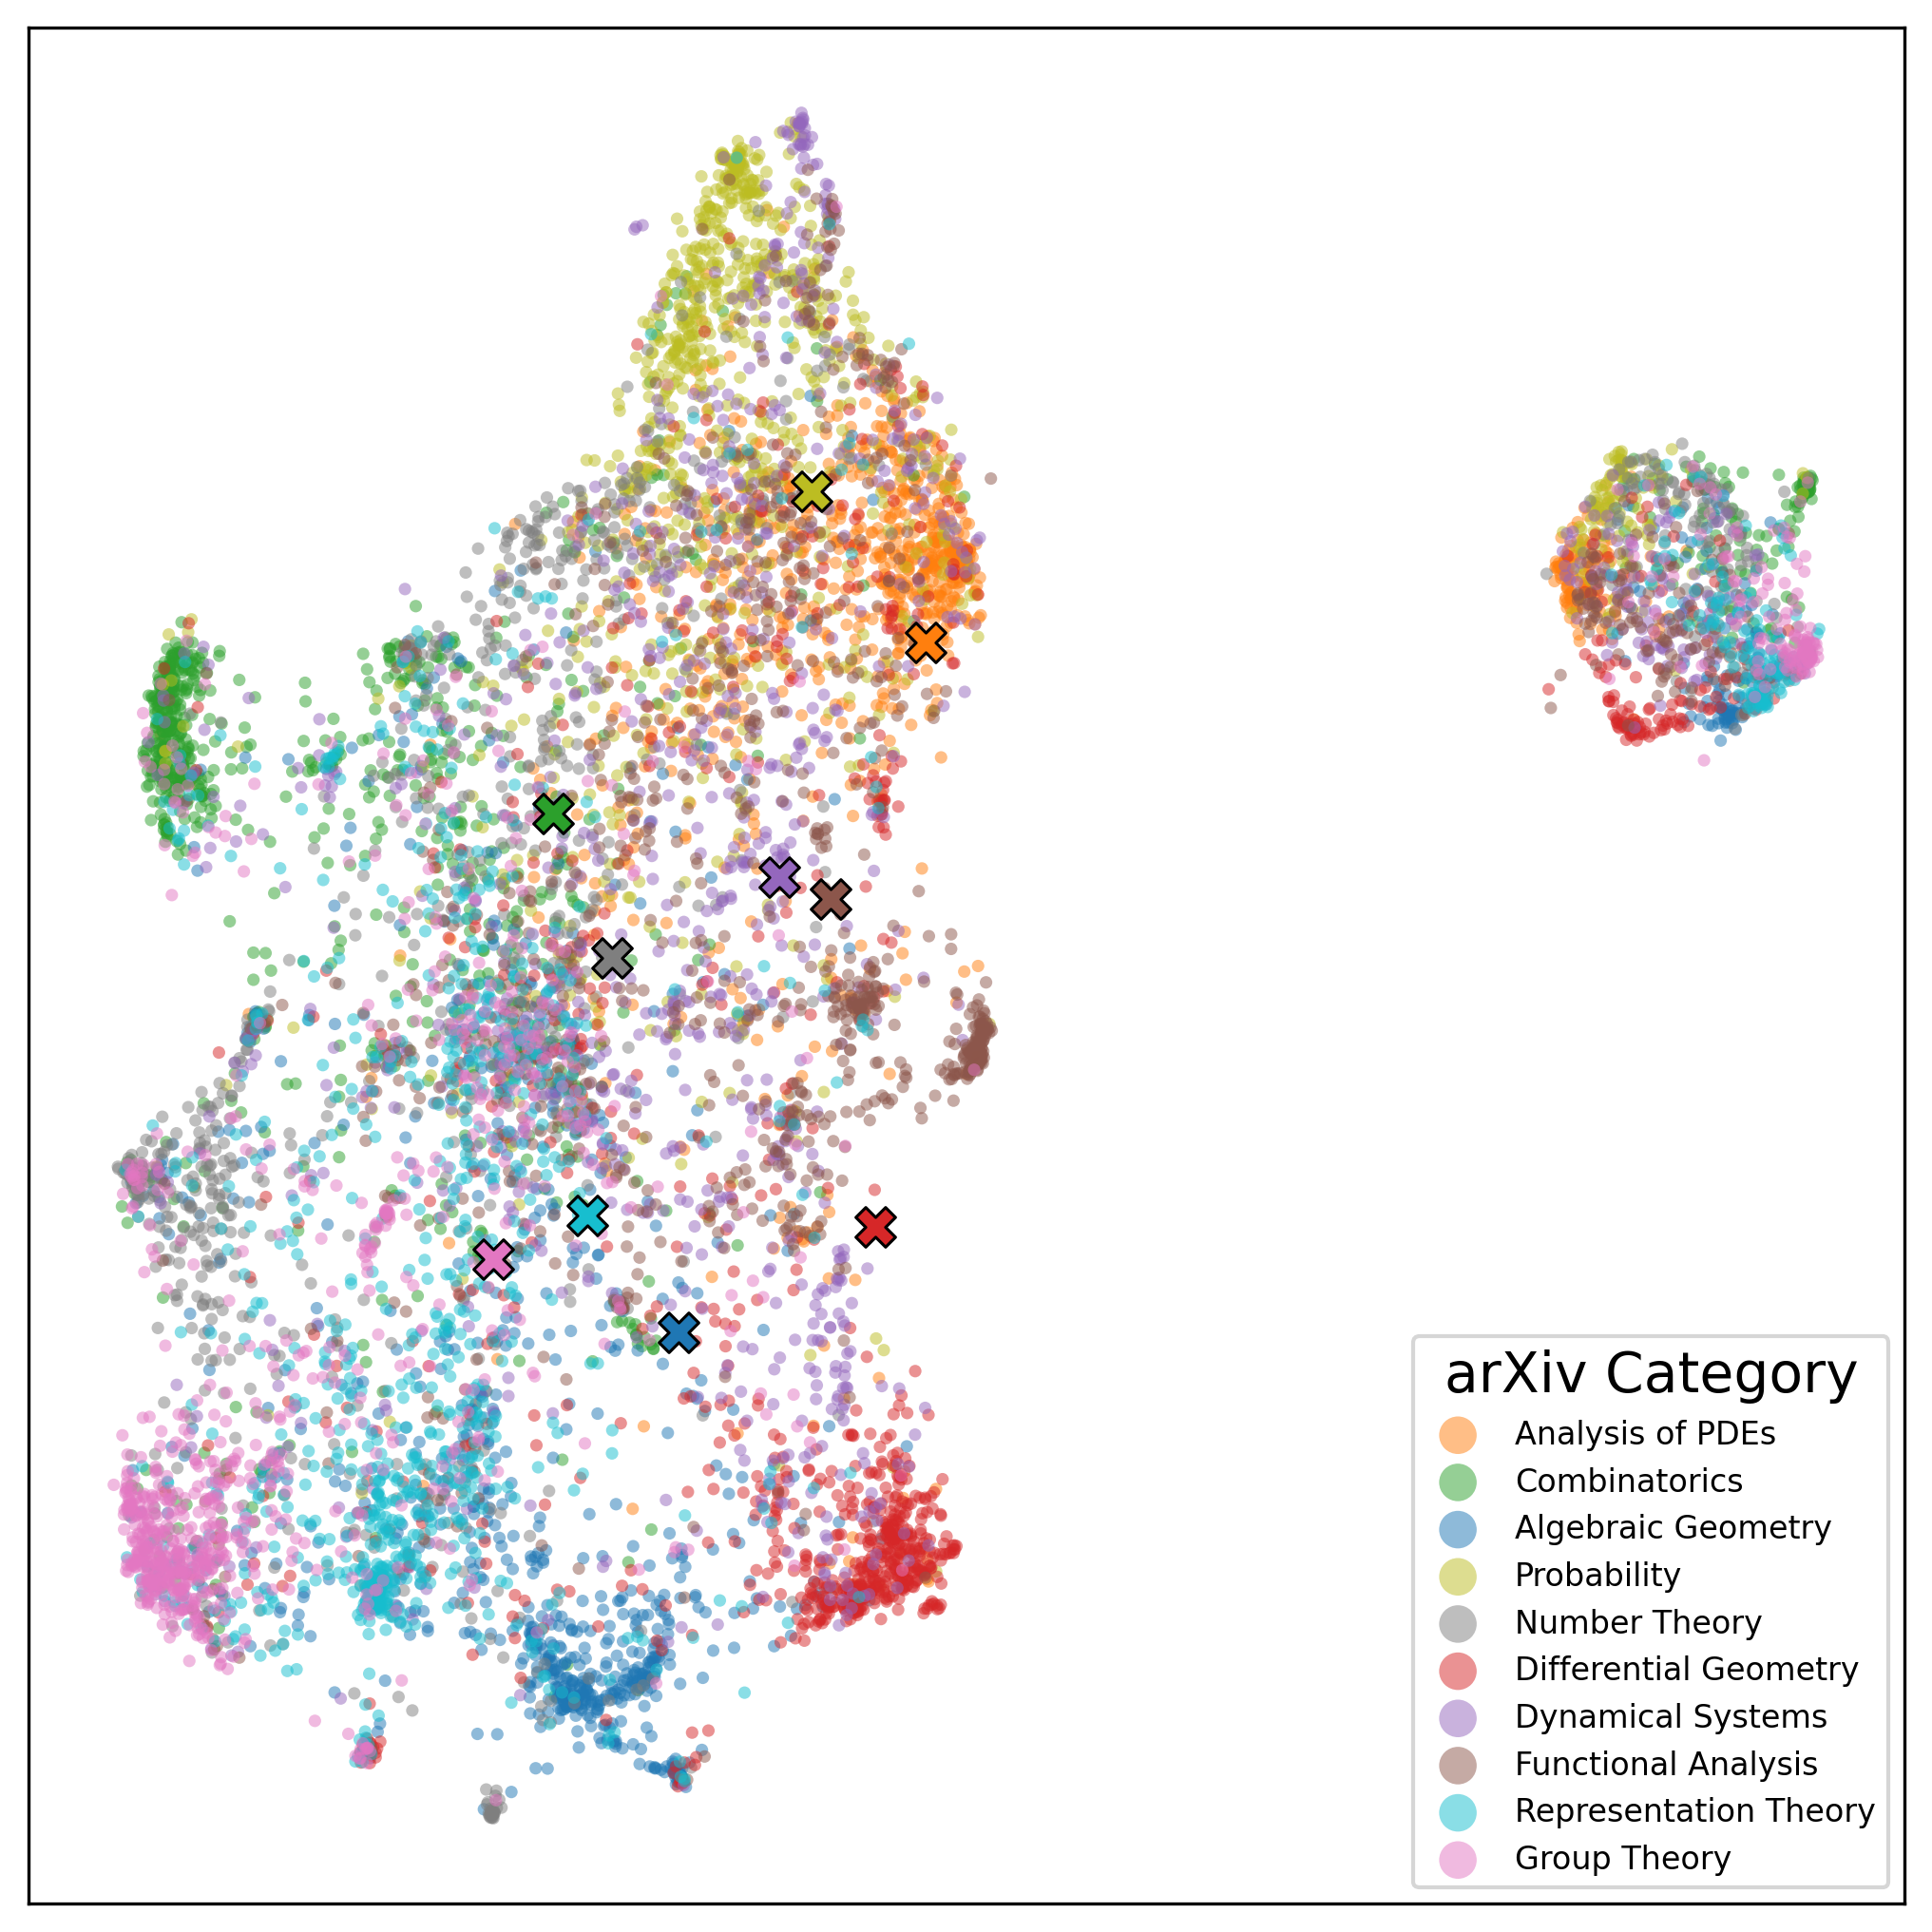

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

for cat in TOP_10:
    mask = cats == cat
    plt.scatter(
        Z_raw[mask,0],
        Z_raw[mask,1],
        s=10,
        color=cat_to_color[cat],
        alpha=0.5,
        label=ARXIV_FULL_NAMES[cat],
        edgecolors='none'
    )

# Centroids
for cat in TOP_10:
    cx, cy = raw_centroids[cat]
    plt.scatter(
        cx, cy,
        marker='X',
        s=100,
        color=cat_to_color[cat],
        edgecolors='black',
        linewidths=0.75,
        zorder=1
    )


plt.xticks([])
plt.yticks([])


plt.legend(
    title="arXiv Category",
    loc="lower right",
    markerscale=3,
    fontsize=8,
)

plt.tight_layout()
plt.show()


In [129]:
plt.savefig("raw_theorem_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("raw_theorem_umap.pdf", dpi=300, bbox_inches="tight")

<Figure size 1920x1440 with 0 Axes>

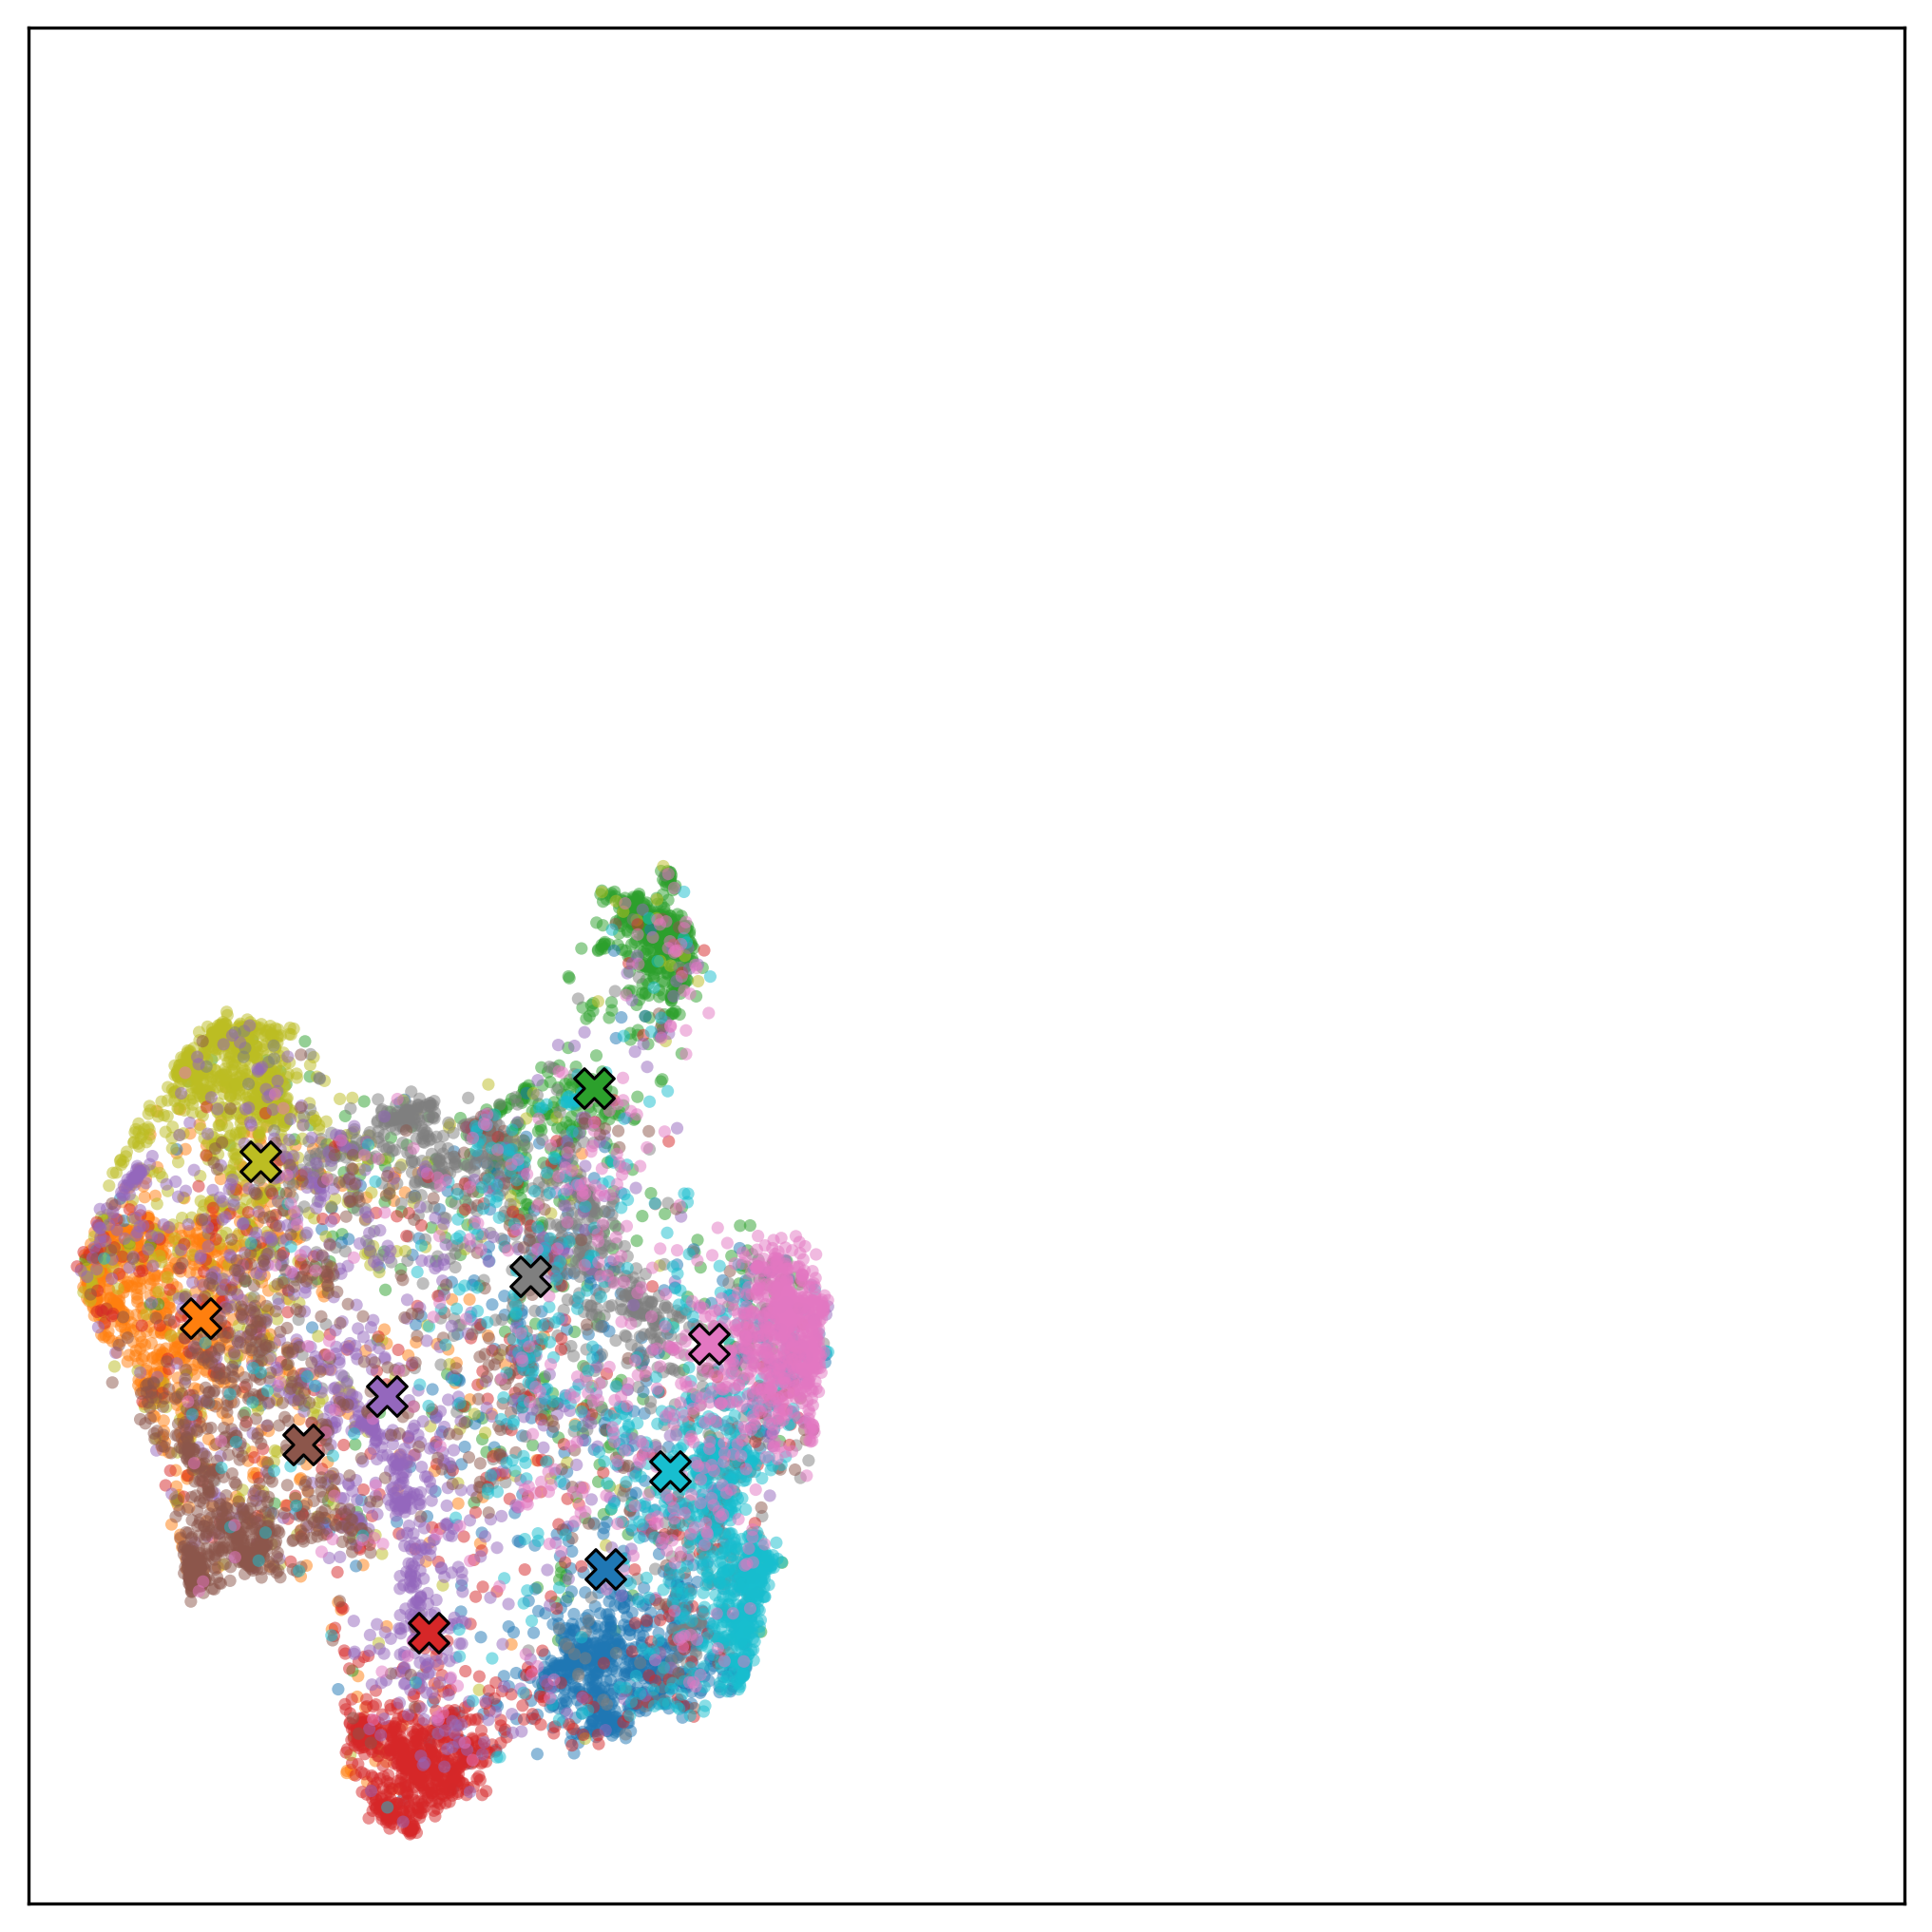

In [138]:
plt.figure(figsize=(7, 7))

for cat in TOP_10:
    mask = cats == cat
    plt.scatter(
        Z_slogan[mask, 0],
        Z_slogan[mask, 1],
        s=10,
        color=cat_to_color[cat],
        alpha=0.5,
        label=ARXIV_FULL_NAMES[cat],
        edgecolors='none',
    )

# Centroids
for cat in TOP_10:
    cx, cy = slogan_centroids[cat]
    plt.scatter(
        cx, cy,
        marker='X',
        s=100,
        color=cat_to_color[cat],
        edgecolors='black',
        linewidths=0.75,
        zorder=1
    )

plt.xticks([])
plt.yticks([])

plt.xlim(xlim)
plt.ylim(ylim)
#
# plt.legend(
#     title="arXiv Category",
#     loc="lower right",
#     markerscale=3,
#     fontsize=8,
# )

plt.tight_layout()
plt.show()

In [130]:
plt.savefig("slogan_theorem_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("slogan_theorem_umap.pdf", dpi=300, bbox_inches="tight")

<Figure size 1920x1440 with 0 Axes>

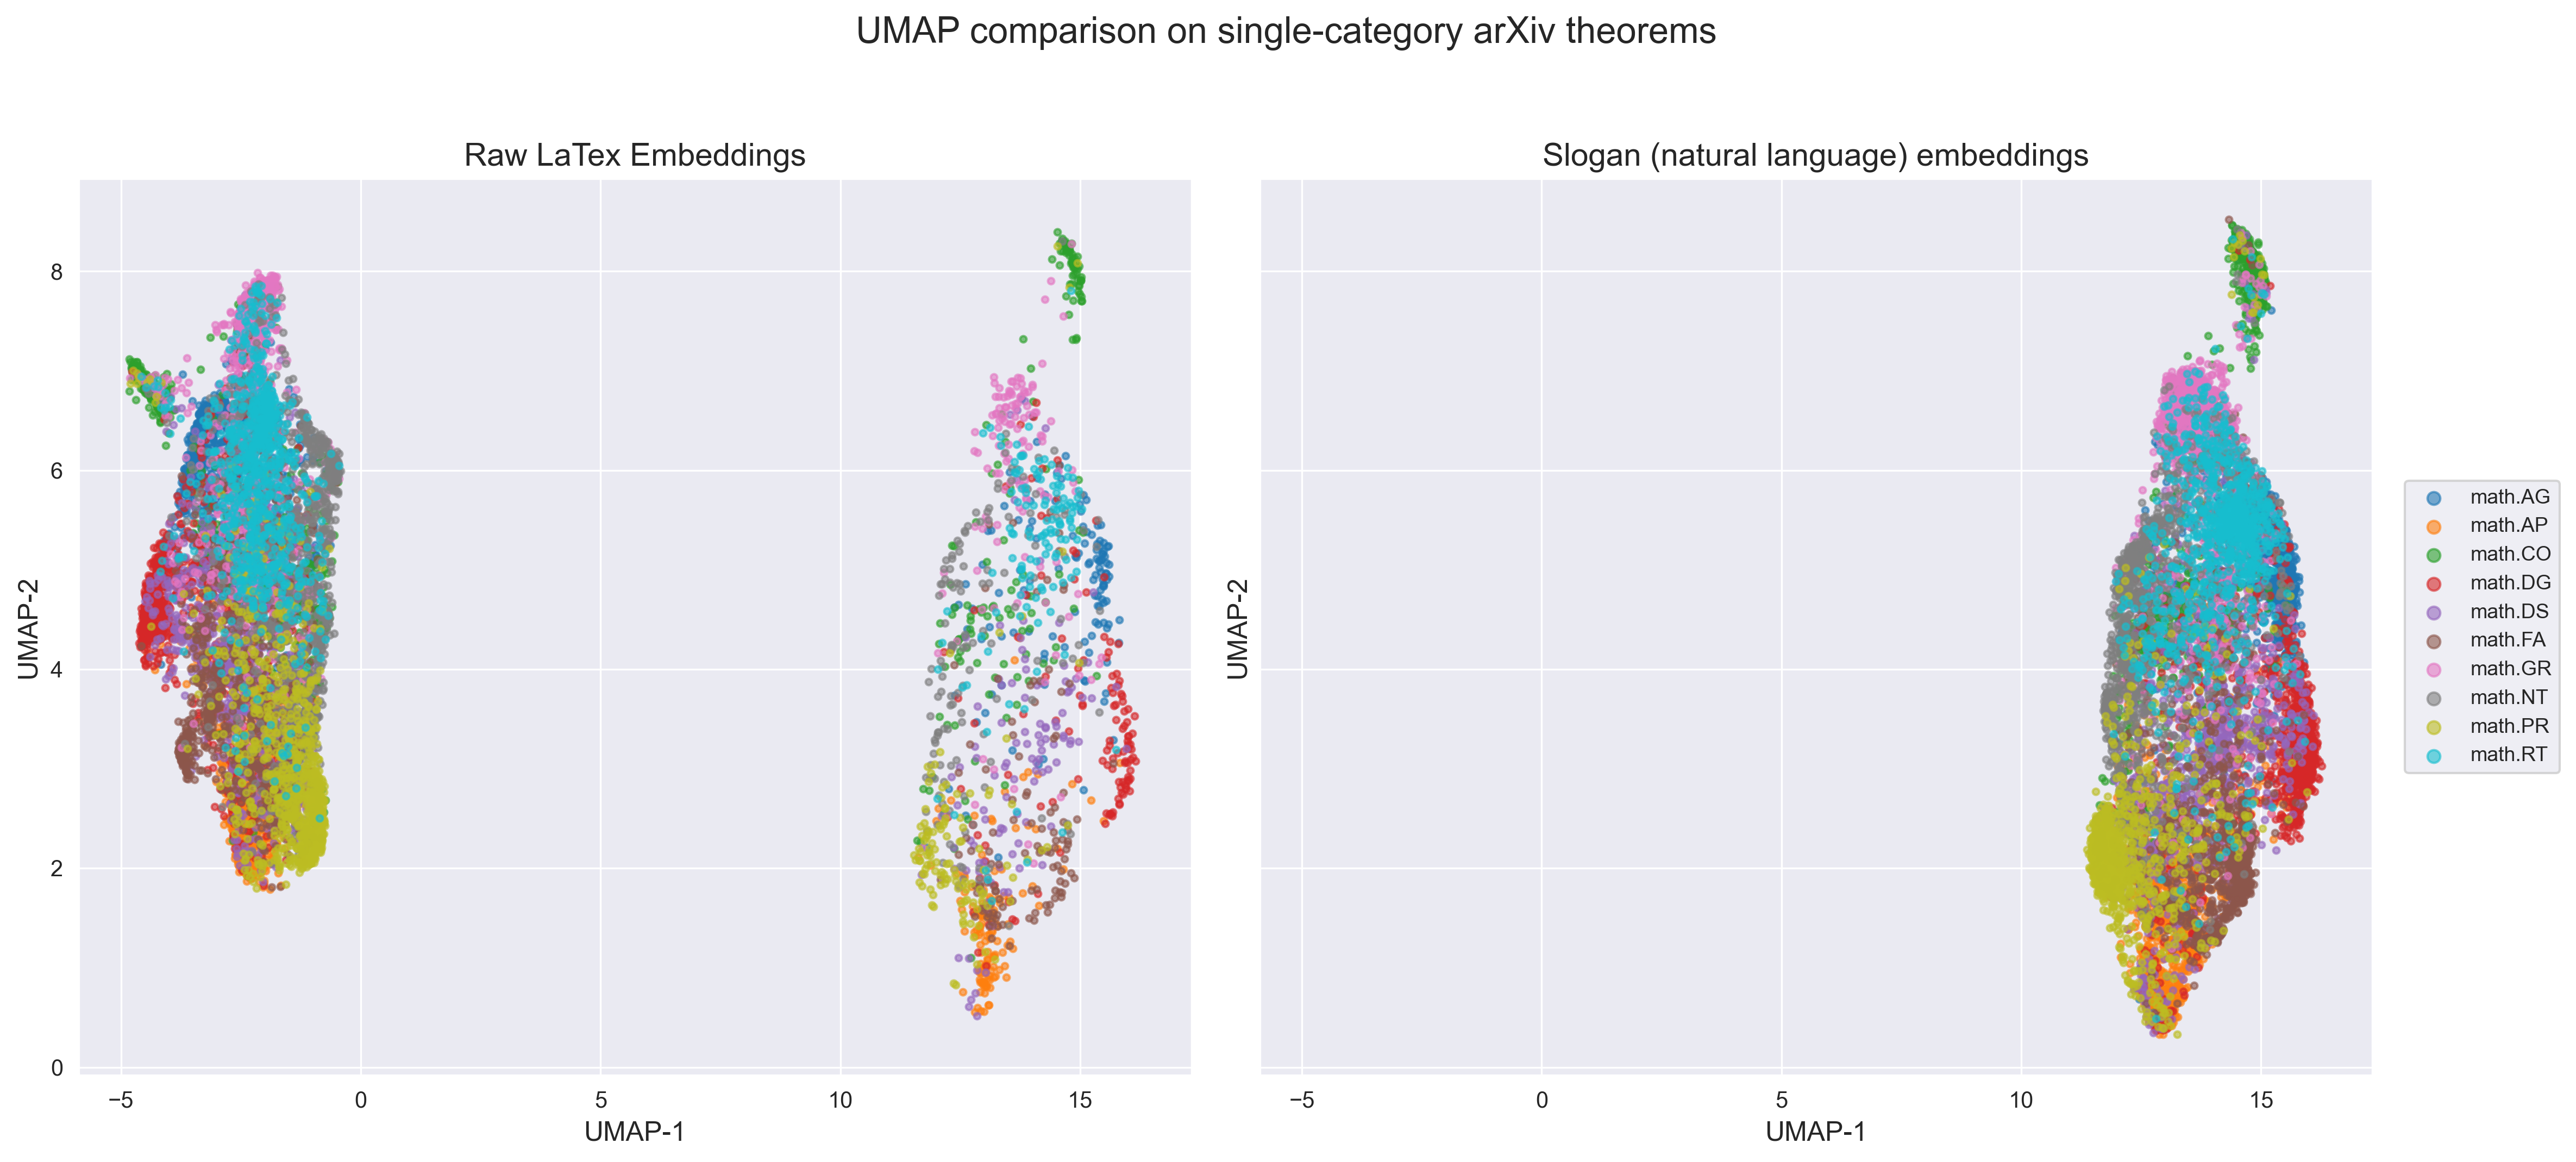

In [78]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    sharex=True,
    sharey=True,
    dpi=300
)

# consistent color map
unique_cats = TOP_10
colors = dict(zip(unique_cats, plt.cm.tab10.colors))

for cat in unique_cats:
    mask = cats == cat
    c = colors[cat]

    axes[0].scatter(
        Z_raw[mask, 0],
        Z_raw[mask, 1],
        s=8,
        alpha=0.6,
        color=c,
        label=cat
    )

    axes[1].scatter(
        Z_slogan[mask, 0],
        Z_slogan[mask, 1],
        s=8,
        alpha=0.6,
        color=c,
        label=cat
    )

axes[0].set_title("Raw LaTex Embeddings", fontsize=14)
axes[1].set_title("Slogan (natural language) embeddings", fontsize=14)

for ax in axes:
    ax.set_xlabel("UMAP-1", fontsize=12)
    ax.set_ylabel("UMAP-2", fontsize=12)
    ax.tick_params(labelsize=10)

# single legend
axes[1].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    markerscale=2
)

plt.suptitle(
    "UMAP comparison on single-category arXiv theorems",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


In [60]:
mask_ag = cats == "math.AG"

X_raw_ag = X_raw[mask_ag]
X_slogan_ag = X_slogan[mask_ag]

print("math.AG sample size:", X_raw_ag.shape[0])

X_raw_ag = l2_normalize(X_raw_ag)
X_slogan_ag = l2_normalize(X_slogan_ag)

# Fit PCA on combined data
X_all_ag = np.vstack([X_raw_ag, X_slogan_ag])

pca = PCA(n_components=2, random_state=42)
Z_all_ag = pca.fit_transform(X_all_ag)

Z_raw_ag = Z_all_ag[:len(X_raw_ag)]
Z_slogan_ag = Z_all_ag[len(X_raw_ag):]

math.AG sample size: 1000


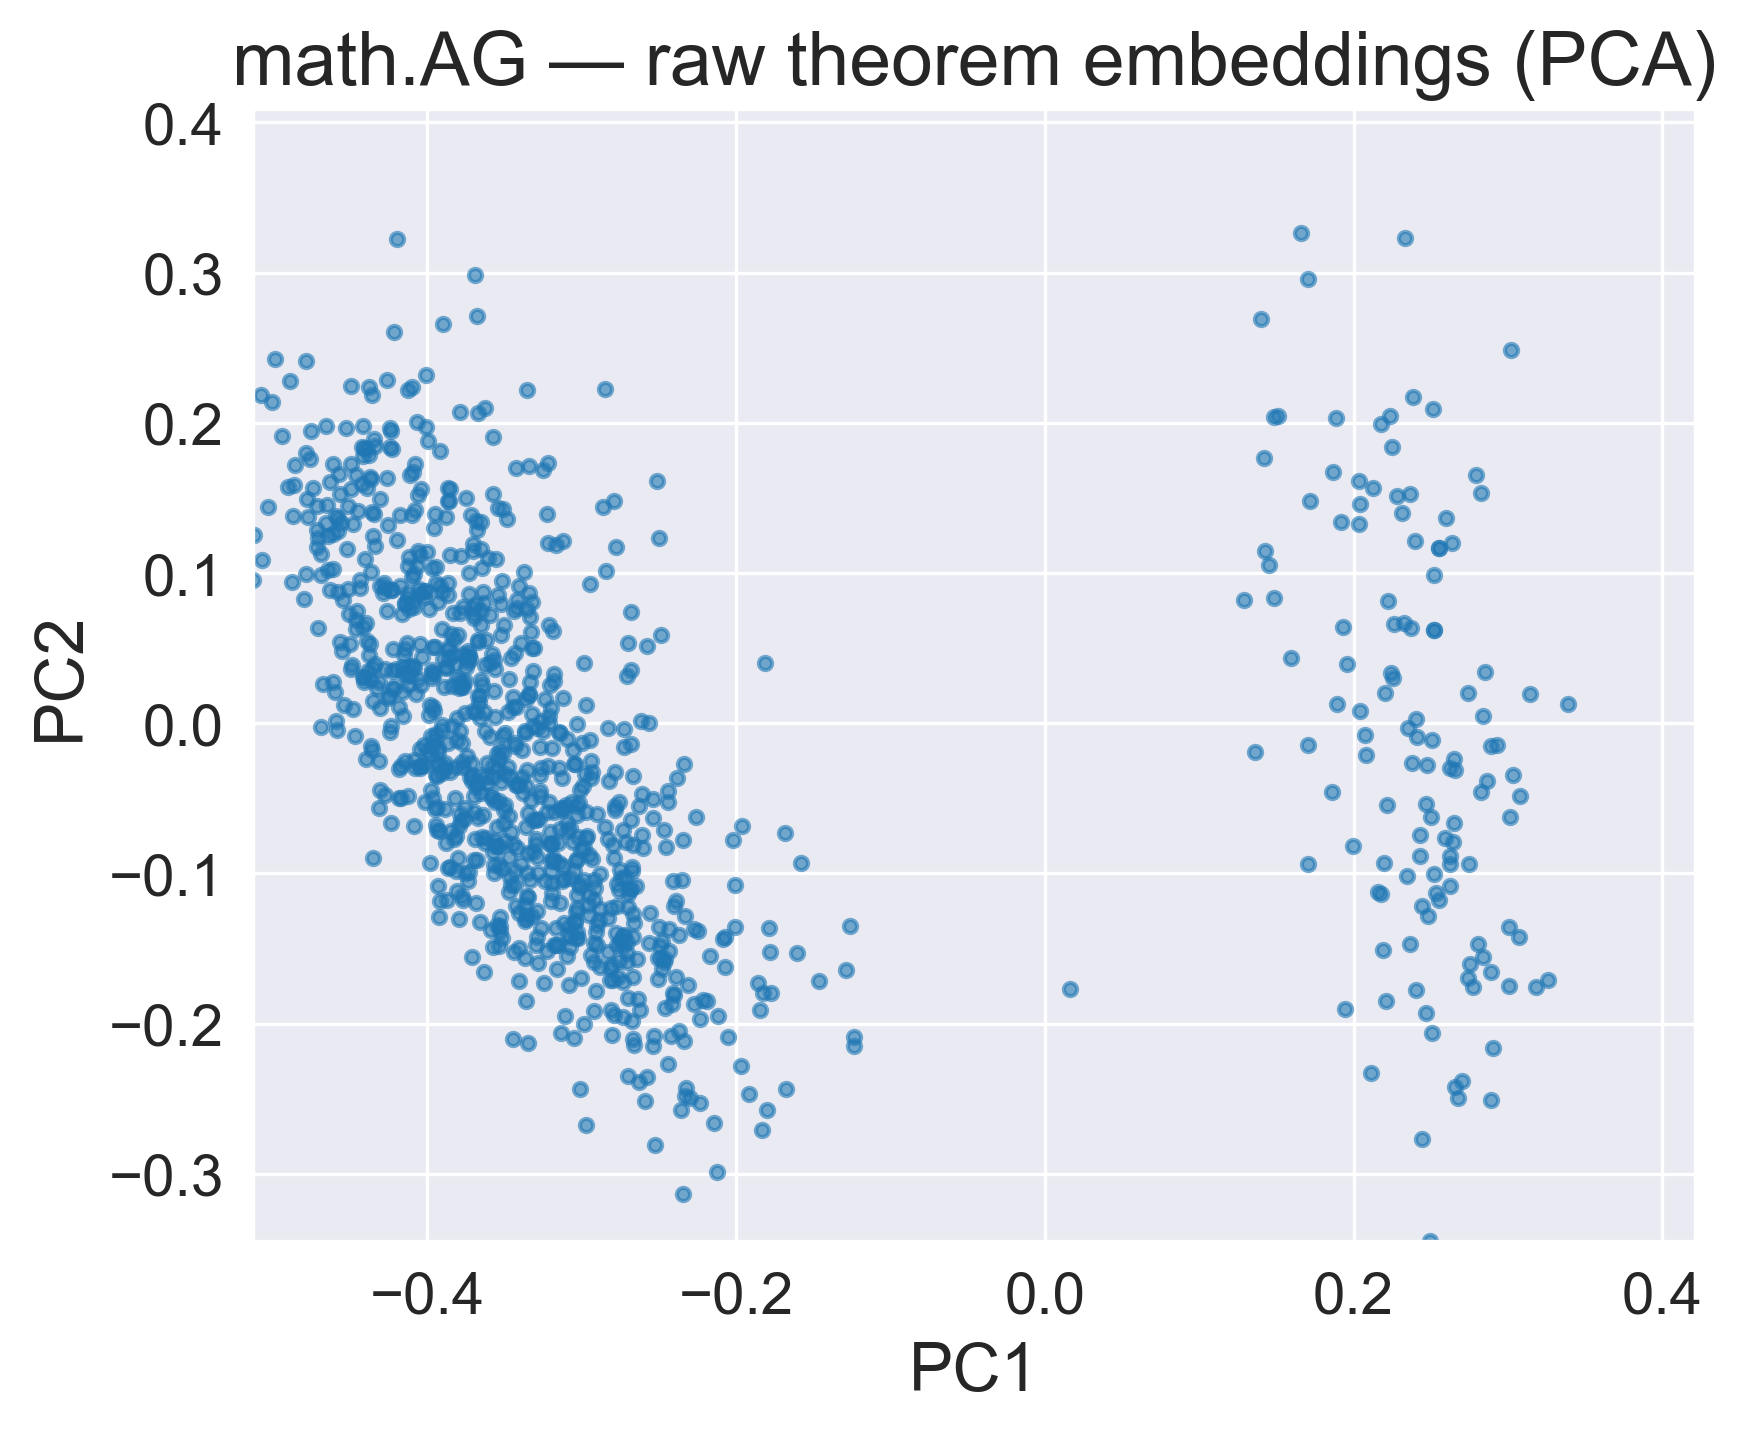

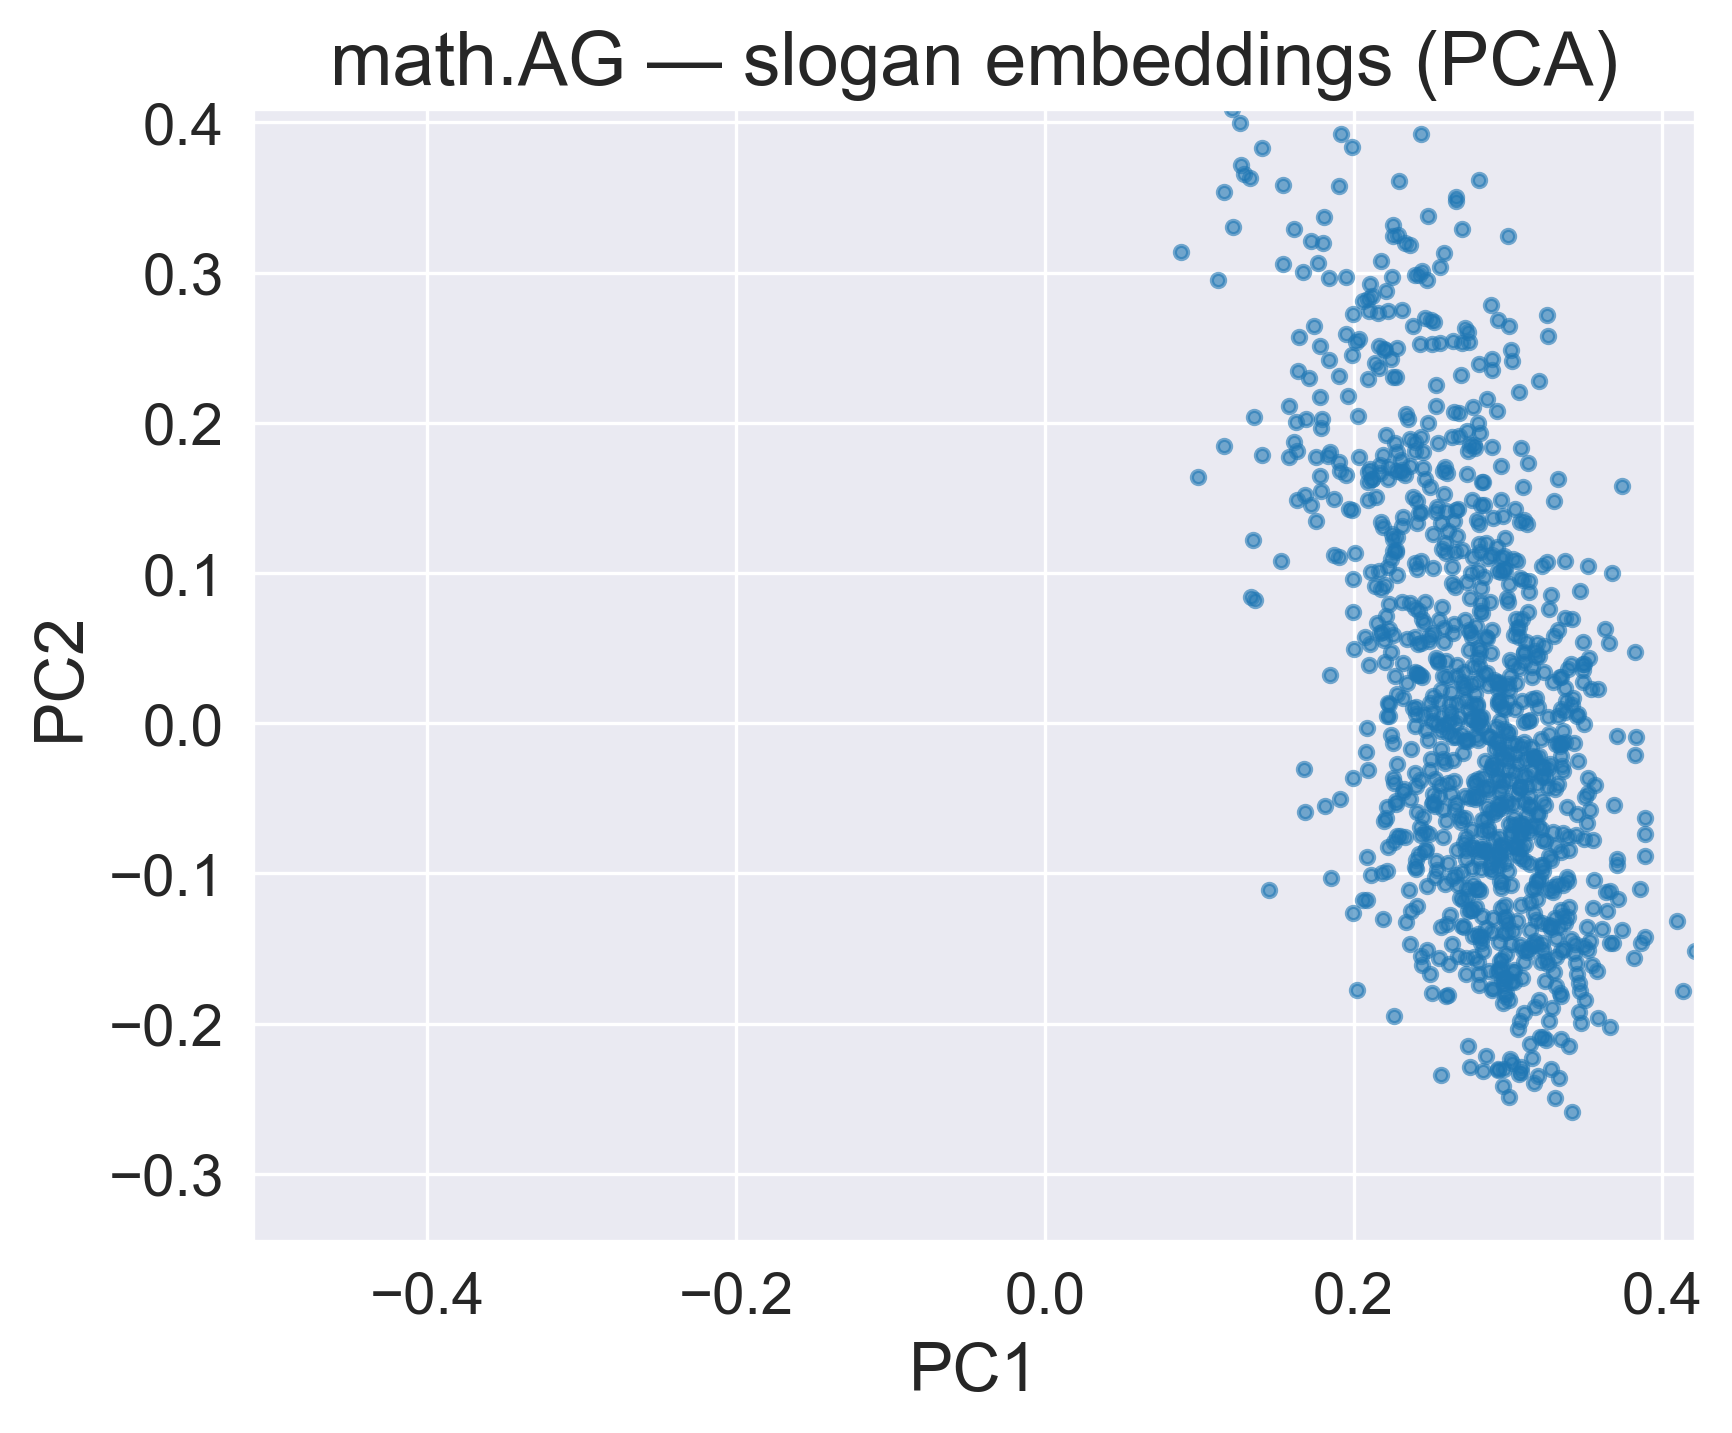

In [61]:
# Shared axis values
Z_all = np.vstack([Z_raw_ag, Z_slogan_ag])
xlim = (Z_all[:, 0].min(), Z_all[:, 0].max())
ylim = (Z_all[:, 1].min(), Z_all[:, 1].max())

# Raw
plt.figure(figsize=(6, 5))
plt.scatter(Z_raw_ag[:, 0], Z_raw_ag[:, 1], s=10, alpha=0.6)
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("math.AG — raw theorem embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Slogan
plt.figure(figsize=(6, 5))
plt.scatter(Z_slogan_ag[:, 0], Z_slogan_ag[:, 1], s=10, alpha=0.6)
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("math.AG — slogan embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [62]:
theorem_ids = np.array([r[0] for r in rows])

np.percentile(Z_raw[:, 0], [5, 25, 50, 75, 95])

array([-4.29294217, -2.71807683, -2.12498605, -1.26882944, 14.02102222])

In [63]:
left_mask  = Z_raw[:, 0] < -3
right_mask = Z_raw[:, 0] > 0

rng = np.random.default_rng(42)

left_indices = rng.choice(
    np.where(left_mask)[0],
    size=10,
    replace=False
)

right_indices = rng.choice(
    np.where(right_mask)[0],
    size=10,
    replace=False
)

left_theorem_ids  = theorem_ids[left_indices]
right_theorem_ids = theorem_ids[right_indices]

left_theorem_ids, right_theorem_ids

(array([19494986, 23703328, 23606810, 23336436, 26022213, 24407330,
        21881607, 19143710, 23064193, 24800019]),
 array([18291218, 17548633, 14685524, 17611458, 17631880, 23360647,
        15022418, 20235133, 17763633, 17784442]))

In [64]:
def fetch_theorem_bodies(theorem_ids):
    theorem_ids = [int(x) for x in theorem_ids]
    conn = get_rds_connection()
    cur = conn.cursor()

    cur.execute(
        """
        SELECT theorem_id, body
        FROM theorem
        WHERE theorem_id = ANY(%s)
        """,
        (list(theorem_ids),)
    )

    rows = cur.fetchall()
    cur.close()
    conn.close()

    return {tid: body for tid, body in rows}

left_bodies  = fetch_theorem_bodies(left_theorem_ids)
right_bodies = fetch_theorem_bodies(right_theorem_ids)

In [65]:
from IPython.display import display, Markdown

def show_bodies(title, bodies):
    display(Markdown(f"## {title}"))
    for tid, body in bodies.items():
        display(Markdown(f"**Theorem ID {tid}**"))
        display(Markdown(f"```latex\n{body}\n```"))

show_bodies("Left manifold", left_bodies)
show_bodies("Right manifold", right_bodies)

## Left manifold

**Theorem ID 19143710**

```latex
Let $S$ be a projective K3 surface. The $\mathbb {Q}$-subalgebra\[  \bigl\langle A^1(S), c_j(S) \bigr\rangle \  \  \  \subset \  A^\ast (S)  \]injects into cohomology under the cycle class map.
```

**Theorem ID 19494986**

```latex
Let $f: X\to Y$ be a dominant morphism of normal varieties and $Z \subset X,Z_Y\subset Y$ be proper closed subsets. Then there exists a commutative diagram\[  \xymatrix{ (X_1,\Delta _1) \ar[d]_{f_1} \ar[r]^{\pi } &  X\ar[d]^{f}\   & \\  (Y_1,\Delta _{Y_1}) \ar[r]^{\phi } &  Y }  \]satisfying the following conditions:\begin{enumerate} \item $\pi $ and $\phi $ are birational morphisms from quasi-projective varieties. 

\item $f_1:(X_1,\Delta _1) \to (Y_1 ,\Delta _{Y_1})$ is toroidal from a quasi-smooth toroidal variety to a smooth variety, and $f_1^{-1}(Y_1 \setminus \Delta _{Y_1})$ is smooth. 

\item $f_1$ is flat. In particular, all the fibers of $f_1$ have the same dimension. 

\item $\pi ^{-1}Z \bigcup \operatorname{Ex}(\pi ) \subseteq \Delta _1$ and $\phi ^{-1}Z_Y \bigcup \operatorname{Ex}(\phi ) \subseteq \Delta _{Y_1}$, where $\operatorname{Ex}(\pi ),\operatorname{Ex}(\phi )$ denote the exceptional loci. 

\end{enumerate}Furthermore, if $Z$ is vertical$/Y$, then $(X_1,\Delta _1^v)$ also satisfies the conditions listed above, except that $\operatorname{Ex}(\pi ) \subseteq \Delta _1$, where $\Delta _1^v$ denotes the vertical part of $\Delta _1$.
```

...

```latex
{\rm \cite{Balakrishnan,BiluParentRebolledo}} If $p\geq 11$ is a prime, then the rational points on $X_s^+(p)$ are cusps or correspond to elliptic curves with complex multiplication.
```

**Theorem ID 20235133**

```latex
Let $N$ be as in definition \ref{fibermixingdef}. There exists a constant $C$ such that\begin{align*}  \Theta _{\mathcal{C}(\text{out}, \overline{w},+)}(\mathcal{L}_{\overline{w}}f,1)\leq C\end{align*}for all $f\in \mathcal{C}(\text{in}, \overline{w}, +B)$ and admissible words $\overline{w}=\overline{w}_{0}\cdots \overline{w}_{N}$.
```

**Theorem ID 23360647**

```latex
Let $\Omega = \{  (x,t) \in {\bf R}^2 \,  | \,  \phi (x) < t \} $ for some Lipschitz function $\phi $, $\| \phi '\| _{L^\infty ({\bf R})} \leq k$. Let $L = \div \,  A \nabla $ be an elliptic operator satisfying (\ref{ellipticity}) with coefficient matrix $A = A(x)$ of measurable functions bounded by $\Lambda $ independent of the $t$-variable and of the form (\ref{form}). Then for each $p>1$ there exists a constant $C(p)$, depending only on $\lambda $, $\Lambda $, $k$ and $p$, such that any function $u \colon \Omega \to {\bf R}$ such that $Lu =0$, and $u(X) = O(|X|^{\delta -1})$ and $|\nabla u(X)| = O(|X|^{\delta -2})$ for all $\delta > 0$ as $|X| \to \infty $, we have\[  \| \widetilde{N}(\nabla {u}) \| _{L^p(\partial \Omega )} \leq C(p)(\| \nabla u\| _{L^p(\partial \Omega )} + \| \mathcal{K}(u_t)\| _{L^p(\partial \Omega )} + \| \mathcal{L}(\widetilde{u_t})\| _{L^p(\partial \Omega )}).  \]
```

In [65]:
left_ids = [int(x) for x in left_theorem_ids]
right_ids = [int(x) for x in right_theorem_ids]

import csv

with open("math_ag_sample.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(
        f,
        quoting=csv.QUOTE_ALL
    )

    writer.writerow(["theorem_id", "manifold", "body"])

    for tid in left_ids:
        writer.writerow([
            tid,
            "left",
            left_bodies.get(tid, "")
        ])

    for tid in right_ids:
        writer.writerow([
            tid,
            "right",
            right_bodies.get(tid, "")
        ])